### Import Libraries

In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### Read Dataset and check the shape and first five columns

In [6]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [7]:
df.shape

(5000, 13)

In [8]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


### Basic data understanding — data types, missing values, duplicate rows, summary statistics

In [9]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [10]:
df.duplicated().sum()

2

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [12]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


### Exploratory Data Analysis (EDA)

#### -> Distribution of the target (`Mental_Health_Score`)

c:\Users\rashe\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

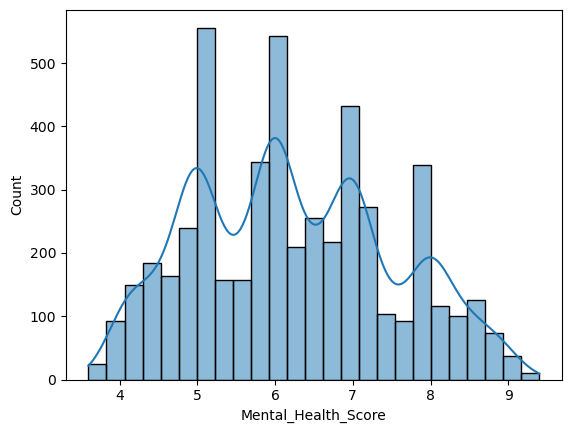

In [13]:
sns.histplot(df['Mental_Health_Score'], kde=True)

#### -> Correlation heatmap

<Axes: >

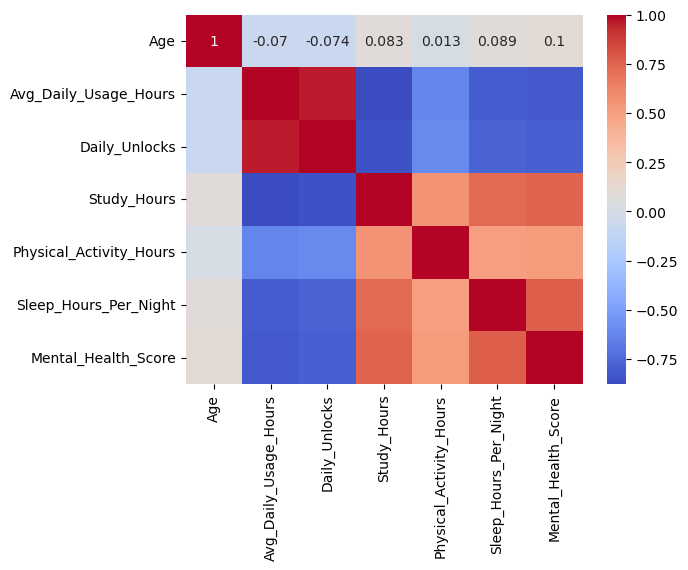

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

#### -> Stress Level vs Mental Health Score

In [15]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [16]:
order = ['Low', 'Medium', 'High', 'Very High']

c:\Users\rashe\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rashe\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rashe\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\rashe\anaconda3\Lib\site-packages\seaborn\categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN befo

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

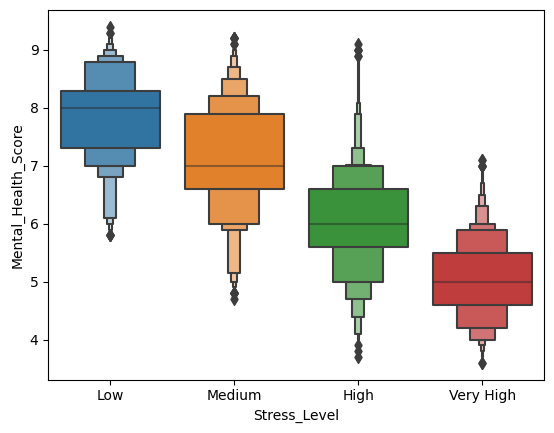

In [17]:
sns.boxenplot(
    x='Stress_Level', 
    y='Mental_Health_Score',
    order=order,
    data=df)

#### -> Daily Usage Hours vs Mental Health Score

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

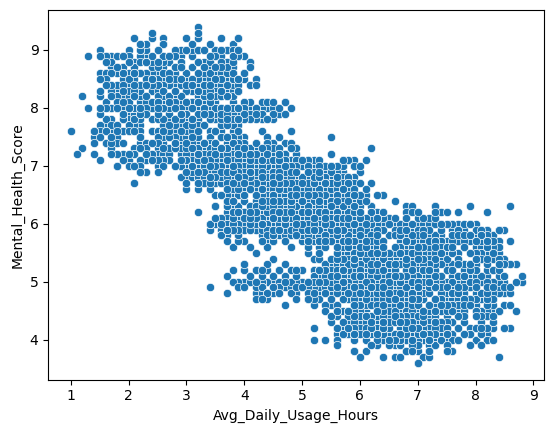

In [18]:
sns.scatterplot(
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score',
    data=df
)

#### -> Sleep Hours vs Mental Health Score

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

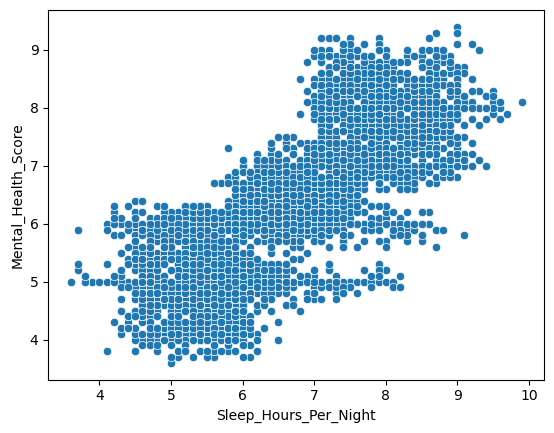

In [19]:
sns.scatterplot(
    x='Sleep_Hours_Per_Night',
    y='Mental_Health_Score',
    data=df
)

#### -> Most Used Platform (Count)

In [20]:
platform_counts = df['Most_Used_Platform'].value_counts()
platform_counts

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

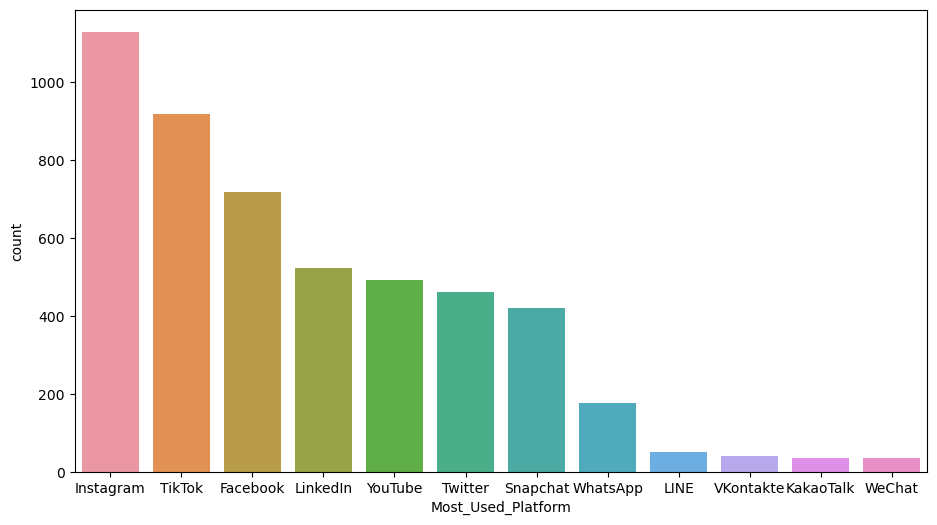

In [21]:
plt.figure(figsize=(11, 6))
sns.countplot(
    x='Most_Used_Platform',
    data=df,
    order=platform_counts.index
)

#### -> Checking Outliers

In [22]:
num_features = df.select_dtypes(include='number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum()) 

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


### Data Cleaning

In [23]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


#### -> Drop duplicates

In [24]:
df = df.drop_duplicates()

#### -> Converting negative or unrealistic value to realistic value

In [25]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [26]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [27]:
df.shape[0]

4998

### Skewness

In [28]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()
# near to zero -> centralized distribution
# negative -> left skewed
# positive (greater than zero) -> right skewed
# when we need to fix the skewness, we can use log transformation or square root transformation.

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

### Feature Engineering

In [29]:
df['Country'].nunique()

111

In [30]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [31]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [32]:
df['Grouped_Country'] = df['Country'].apply(group_countries)

In [33]:
df['Grouped_Country'].value_counts()

Grouped_Country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

### Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
skewed_col = ['Study_Hours']
other_numeric_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
                      'Sleep_Hours_Per_Night', 'Physical_Activity_Hours']
ordinal_col = ['Stress_Level']
nominal_col = ['Gender', 'Most_Used_Platform', 'Grouped_Country', 'Purpose_Of_Use']




feature_col = skewed_col + other_numeric_cols + ordinal_col + nominal_col
X = df[feature_col]
y = df['Mental_Health_Score']




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

### Preprocessing using ColumnTransformer

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#### -> Pipeline for skewed feature

In [37]:
skewed_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('Scale', StandardScaler())
])

#### -> Pipeline for Numeric features

In [38]:
plain_numeric_pipeline = Pipeline(steps=[
    ('Scale', StandardScaler())
])

#### -> Pipeline for Ordinal feature

In [39]:
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#### -> Pipeline for Normal features

In [40]:
normal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

#### -> ColumnTransformer -> Using for defining which pipeline is prepared for which feature or column

In [41]:
preprocessor = ColumnTransformer(transformers=[
    ('skewed_pipeline', skewed_pipeline, skewed_col),
    ('plain_numeric_pipeline', plain_numeric_pipeline, other_numeric_cols),
    ('ordinal_pipeline', ordinal_pipeline, ordinal_col),
    ('normal_pipeline', normal_pipeline, nominal_col)
])

### Build a Pipeline

#### -> Baseline: Linear Regression

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mse_testing = mean_squared_error(y_test, lr_preds)
lr_mse_training = mean_squared_error(y_train, lr_preds_train)
lr_mae_testing = mean_absolute_error(y_test, lr_preds)
lr_mae_training = mean_absolute_error(y_train, lr_preds_train)

print(f"R2 score for testing data: {lr_r2_testing}")
print(f"R2 score for training data: {lr_r2_training}")
print(f"MSE for testing data: {lr_mse_testing}")
print(f"MSE for training data: {lr_mse_training}")
print(f"MAE for testing data: {lr_mae_testing}")
print(f"MAE for training data: {lr_mae_training}")

R2 score for testing data: 0.7397941782343004
R2 score for training data: 0.7235798140529034
MSE for testing data: 0.4570195506836025
MSE for training data: 0.43693864571481905
MAE for testing data: 0.5367254717461363
MAE for training data: 0.5194232660609247


#### -> Random Forest (default settings)

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_train)
rf_mse_testing = mean_squared_error(y_test, rf_preds)
rf_mae_testing = mean_absolute_error(y_test, rf_preds)


print(f"R2 score for testing data: {rf_r2_testing}")
print(f"R2 score for training data: {rf_r2_training}")
print(f"MSE for testing data: {rf_mse_testing}")
print(f"MAE for testing data: {rf_mae_testing}")

R2 score for testing data: 0.8759990449093025
R2 score for training data: 0.9807677620800926
MSE for testing data: 0.21779243982833335
MAE for testing data: 0.34852823333333344


#### -> Hyperparameter Tuning the Random Forest

In [44]:
from sklearn.model_selection import RandomizedSearchCV

In [45]:
param_grid = {
    'random_forest__n_estimators' : [100, 200, 300],
    'random_forest__max_depth' : [5, 10, 15],
    'random_forest__min_samples_split' : [2, 5, 10],
    'random_forest__min_samples_leaf' : [1, 2, 4]
}


random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skewed_pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('Scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric_pipeline',
                                                                               Pipeline(steps=[('Scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unl...
                                                                                'Most_Used_Platform',
                                                                                'Grouped_Country',
                                                                                'Purpose_Of_Use'])])),
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random_forest__max_depth': [5, 10, 15],
                                        'random_forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random_forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random_forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [46]:
random_search.best_params_

{'random_forest__n_estimators': 200,
 'random_forest__min_samples_split': 5,
 'random_forest__min_samples_leaf': 2,
 'random_forest__max_depth': 15}

In [47]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)

print(f"R2 score for testing data: {r2_score(y_test, rf_best_preds)}")
print(f"MAE score for testing data: {mean_absolute_error(y_test, rf_best_preds)}")

R2 score for testing data: 0.8634243587930799
MAE score for testing data: 0.370774948763411


### Model Evaluation

In [48]:
from sklearn.metrics import mean_squared_error

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_best_preds))

rf_tuned_preds = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)



results = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest', 'Tuned Random Forest'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE' : [lr_mae_testing, rf_mae_testing, rf_tuned_mae],
    'RMSE' : [lr_rmse, rf_rmse, rf_tuned_rmse]
})


print(results)

                 Model        R2  Training R2       MAE      RMSE
0    Linear Regression  0.739794     0.723580  0.536725  0.676032
1        Random Forest  0.875999     0.980768  0.348528  0.489774
2  Tuned Random Forest  0.863424     0.954070  0.370775  0.489774


### Save the Model

In [49]:
import joblib
joblib.dump(rf_pipeline, 'mental_health_model.pkl')

['mental_health_model.pkl']

#### -> Next Steps

build a FastAPI backend with Pydantic request validation that loads `mental_health_model.pkl` and exposes a /predict endpoint, then connect a simple frontend, then deploy both so this becomes a live, clickable demo.

In [50]:
import pandas
print(pandas.__version__)


2.1.4


In [52]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Grouped_Country']

In [53]:
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Turkey',
 'Mexico',
 'France']

In [54]:
df['Academic_Level'].unique()

array(['Undergraduate', 'Graduate', 'High School'], dtype=object)

In [55]:
df['Most_Used_Platform'].unique()

array(['Facebook', 'LinkedIn', 'Instagram', 'Snapchat', 'Twitter',
       'YouTube', 'TikTok', 'LINE', 'KakaoTalk', 'VKontakte', 'WhatsApp',
       'WeChat'], dtype=object)

In [56]:
df['Purpose_Of_Use'].unique()

array(['Networking', 'Education', 'Entertainment', 'News'], dtype=object)